# VLSTM: Variable-Selection + LSTM for End-to-End Portfolio Learning

**Docker image**: `ml4t-gpu`

> **GPU recommended**: This notebook trains models with PyTorch/CUDA. It will run on CPU
> but training may be slow. For GPU acceleration:
> ```bash
> docker compose run --rm ml4t-gpu python 17_portfolio_construction/12_vlstm_portfolio.py
> ```

This notebook implements a TFT-style variable-selection block in front of an LSTM encoder.

**Learning objectives**:
- Build a TFT-style Gated Residual Network (GRN) and Variable Selection Network (VSN)
- Stack the VSN in front of an LSTM to form the VLSTM encoder
- Emit a scalar signal $p_{i,t} \in (-1,1)$ via tanh and convert it to a volatility-targeted long-short position
- Train with a cost-aware pooled Sharpe loss on realized portfolio returns
- Compare VLSTM to the plain LSTM baseline (`11_dl_portfolio_allocation`) and heuristic allocators

**Book Reference**: Chapter 17, Section 17.8 (Deep learning for portfolio construction)

**Prerequisites**: `11_dl_portfolio_allocation`

## 1. Setup

In [1]:
"""VLSTM allocator with TFT-style variable selection and volatility targeting."""

import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset

from data import load_etfs
from utils.reproducibility import set_global_seeds
from utils.style import COLORS, show_with_alt

In [2]:
# 0 = full ETF universe.
MAX_SYMBOLS = 0
N_EPOCHS = 200
SEQ_LEN = 63  # ~3 months lookback, matches notebook 11.
D_MODEL = 32  # GRN / VSN hidden dimension.
SEED = 42
LSTM_HIDDEN = 64
DROPOUT = 0.0  # Exact pooled two-pass gradients require deterministic chunk recomputation.
LR = 1e-3
WEIGHT_DECAY = 1e-5
BATCH_SIZE = 32
VOL_TARGET_ANN = 0.15  # Target annualized portfolio volatility.
VOL_LOOKBACK = 63  # Rolling window for per-asset volatility estimate.
TURNOVER_COST_BPS = 5.0  # One-way cost in the loss (basis points).
COST_WEIGHT = 1.0  # Scales the turnover penalty in the loss.

### Determinism

Two runs of the same code give the same weights only if every source of randomness is pinned.
`set_global_seeds` covers Python, NumPy and Torch; the cuDNN settings and the cuBLAS workspace
variable below cover the GPU kernels, which otherwise pick an algorithm by timing and so vary
between runs. Dropout is set to zero for the same reason: the pooled loss recomputes each chunk
in a second pass, and a stochastic layer would make the two passes disagree.

In [3]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")

set_global_seeds(SEED)
torch.use_deterministic_algorithms(True, warn_only=True)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

Device: cuda


## 2. Data: ETF Universe

Same universe as `11_dl_portfolio_allocation` so the architectural comparison is
apples-to-apples on the same test period.

In [4]:
US_EQUITY = ["SPY", "QQQ", "IWM", "VTV", "VUG", "MDY"]
INTERNATIONAL = ["EFA", "EEM", "VEA", "VWO"]
FIXED_INCOME = ["AGG", "TLT", "LQD", "HYG", "TIP", "SHY", "IEF"]
ALTERNATIVES = ["GLD", "SLV", "VNQ", "DBC"]
SECTORS = ["XLF", "XLE", "XLK", "XLV", "XLI", "XLU", "XLP", "XLY"]
UNIVERSE = [*US_EQUITY, *INTERNATIONAL, *FIXED_INCOME, *ALTERNATIVES, *SECTORS]

if MAX_SYMBOLS > 0:
    UNIVERSE = UNIVERSE[:MAX_SYMBOLS]

In [5]:
etf_data = load_etfs()
prices = (
    etf_data.filter(pl.col("symbol").is_in(UNIVERSE))
    .select(["timestamp", "symbol", "close"])
    .pivot(on="symbol", index="timestamp", values="close")
    .sort("timestamp")
    .to_pandas()
    .set_index("timestamp")
)
prices = prices[[c for c in UNIVERSE if c in prices.columns]]
coverage_threshold = max(1, int(prices.shape[1] * 0.8))
prices = prices.dropna(thresh=coverage_threshold)
prices = prices.ffill()
prices = prices.dropna()
UNIVERSE = list(prices.columns)
N_ASSETS = len(UNIVERSE)

print(f"Price panel: {prices.shape[0]} dates × {N_ASSETS} assets")
print(f"Date range:  {prices.index[0]:%Y-%m-%d} → {prices.index[-1]:%Y-%m-%d}")

Price panel: 4639 dates × 29 assets
Date range:  2007-07-26 → 2025-12-31


## 3. Feature Engineering and Volatility Estimate

Features match notebook 11 for a like-for-like comparison: multi-horizon returns and
21-day realized volatility. The volatility-targeting layer uses a longer rolling
estimate that feeds into the position sizing rather than into the model input.

In [6]:
returns = prices.pct_change(fill_method=None).fillna(0.0)

HORIZONS = [1, 5, 21, 63]
features_list = [(prices / prices.shift(h) - 1.0).fillna(0.0).values for h in HORIZONS]
features_list.append(returns.rolling(21, min_periods=5).std().fillna(0.0).values)
features = np.stack(features_list, axis=-1).astype(np.float32)
N_FEATURES = features.shape[-1]

# Volatility estimate for the position layer (used for vol targeting).
vol_estimate_frame = returns.rolling(VOL_LOOKBACK, min_periods=21).std().ffill()
assert not vol_estimate_frame.iloc[SEQ_LEN - 1 : -1].isna().any().any()
vol_estimate = vol_estimate_frame.fillna(0.0).clip(lower=1e-4).values.astype(np.float32)

fwd_returns = returns.shift(-1).fillna(0.0).values.astype(np.float32)

print(f"Feature tensor: {features.shape} (T, N, F)")
print(f"Vol estimate:   {vol_estimate.shape}")

Feature tensor: (4639, 29, 5) (T, N, F)
Vol estimate:   (4639, 29)


## 4. Train / Validation / Test Split

Walk-forward: 60/20/20. Same split rule as notebook 11.

In [7]:
dates = prices.index
n_dates = len(dates)
train_end = int(n_dates * 0.6)
val_end = int(n_dates * 0.8)

print(f"Train: {dates[0]:%Y-%m-%d} → {dates[train_end - 1]:%Y-%m-%d} ({train_end} days)")
print(
    f"Val:   {dates[train_end]:%Y-%m-%d} → {dates[val_end - 1]:%Y-%m-%d} ({val_end - train_end} days)"
)
print(
    f"Test decisions: {dates[val_end]:%Y-%m-%d} → {dates[-2]:%Y-%m-%d} "
    f"({n_dates - val_end - 1} days)"
)
print(f"Last realized-return date: {dates[-1]:%Y-%m-%d} (not a decision origin)")

Train: 2007-07-26 → 2018-08-13 (2783 days)
Val:   2018-08-14 → 2022-04-20 (928 days)
Test decisions: 2022-04-21 → 2025-12-30 (927 days)
Last realized-return date: 2025-12-31 (not a decision origin)


## 5. Dataset

Each example provides a feature-history window and exactly one forward-return endpoint.
Validation and test windows may use prior feature history, but their scored labels remain
strictly inside their own partition.

In [8]:
class VLSTMDataset(Dataset):
    """Feature-history windows with one decision endpoint each."""

    def __init__(self, features, fwd_ret, vol_est, start_idx, end_idx, seq_len):
        self.features = features
        self.fwd_ret = fwd_ret
        self.vol_est = vol_est
        self.seq_len = seq_len
        self.indices = np.arange(
            max(start_idx, seq_len - 1),
            min(end_idx, len(features) - 1),
        )

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        t = self.indices[idx]
        sl = slice(t - self.seq_len + 1, t + 1)
        return (
            torch.from_numpy(self.features[sl]),
            torch.from_numpy(self.fwd_ret[t]),
            torch.from_numpy(self.vol_est[t]),
        )

Instantiate disjoint endpoint datasets and chronological loaders.

In [9]:
train_ds = VLSTMDataset(features, fwd_returns, vol_estimate, 0, train_end, SEQ_LEN)
val_ds = VLSTMDataset(features, fwd_returns, vol_estimate, train_end, val_end, SEQ_LEN)
test_ds = VLSTMDataset(features, fwd_returns, vol_estimate, val_end, n_dates, SEQ_LEN)

print(f"Train windows: {len(train_ds)}, Val: {len(val_ds)}, Test: {len(test_ds)}")
assert dates[train_end - 1] < dates[train_end] <= dates[val_end - 1] < dates[val_end]
assert train_ds.indices[-1] == train_end - 1
assert val_ds.indices[0] == train_end and val_ds.indices[-1] == val_end - 1
assert test_ds.indices[0] == val_end and test_ds.indices[-1] == n_dates - 2
assert len(set(train_ds.indices) & set(val_ds.indices)) == 0
assert len(set(val_ds.indices) & set(test_ds.indices)) == 0

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)
val_loader = DataLoader(val_ds, batch_size=64, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=64, shuffle=False)

Train windows: 2721, Val: 928, Test: 927


## 6. Gated Residual Network (GRN)

The TFT building block (Lim et al. 2021). The GRN applies a non-linear transformation
gated by a GLU and wrapped in a residual connection with LayerNorm:

$$\eta_2 = W_2 \cdot \text{ELU}(W_1 x + b_1) + b_2, \quad \text{GRN}(x) = \text{LayerNorm}(x + \text{GLU}(\eta_2)).$$

GLU gating lets the network suppress features whose contribution is noise, which is
crucial in the financial setting where most inputs are weakly predictive.

In [10]:
class GatedResidualNetwork(nn.Module):
    """TFT-style gated residual network with optional skip projection."""

    def __init__(self, input_dim: int, hidden_dim: int, output_dim: int, dropout: float = 0.1):
        super().__init__()
        self.skip = nn.Identity() if input_dim == output_dim else nn.Linear(input_dim, output_dim)
        self.dense1 = nn.Linear(input_dim, hidden_dim)
        self.dense2 = nn.Linear(hidden_dim, output_dim)
        self.gate = nn.Linear(output_dim, 2 * output_dim)
        self.dropout = nn.Dropout(dropout)
        self.norm = nn.LayerNorm(output_dim)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        skip = self.skip(x)
        h = F.elu(self.dense1(x))
        h = self.dense2(h)
        h = self.dropout(h)
        a, b = self.gate(h).chunk(2, dim=-1)
        gated = a * torch.sigmoid(b)
        return self.norm(skip + gated)

## 7. Variable Selection Network (VSN)

For each (asset, time) cell, the VSN projects every scalar feature through its own GRN
into a $d$-dimensional embedding, computes softmax selection weights from the flattened
feature vector, and returns the selection-weighted sum of embeddings.

$$v_{i,t} = \text{softmax}_f \big(\text{GRN}_{\text{sel}}(x_{i,t})\big), \qquad
h_{i,t} = \sum_f v_{i,t,f} \cdot \text{GRN}_f(x_{i,t,f}).$$

This is the core ingredient that distinguishes VLSTM from a plain LSTM encoder: the
model learns which features are worth listening to at each point in the window.

In [11]:
class VariableSelectionNetwork(nn.Module):
    """TFT-style variable selection over per-feature GRN embeddings."""

    def __init__(self, n_features: int, d_model: int, dropout: float = 0.1):
        super().__init__()
        self.n_features = n_features
        self.d_model = d_model
        self.feature_grns = nn.ModuleList(
            [GatedResidualNetwork(1, d_model, d_model, dropout) for _ in range(n_features)]
        )
        self.selector = GatedResidualNetwork(n_features, d_model, n_features, dropout)

    def forward(self, x: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        # x: (B, T, N, F) with per-feature scalar inputs.
        sel_logits = self.selector(x)  # (B, T, N, F)
        sel_weights = torch.softmax(sel_logits, dim=-1)

        embeddings = []
        for f_idx, grn in enumerate(self.feature_grns):
            e = grn(x[..., f_idx : f_idx + 1])  # (B, T, N, d_model)
            embeddings.append(e)
        embeddings = torch.stack(embeddings, dim=-2)  # (B, T, N, F, d_model)

        gated = sel_weights.unsqueeze(-1) * embeddings
        return gated.sum(dim=-2), sel_weights

## 8. VLSTM: Variable Selection + Shared-Weight LSTM + Scalar Head

Every asset is processed by the same LSTM (shared weights, per-asset state), which is
standard for this class of models: the architecture is the inductive bias and the asset
identity is expressed only through its feature sequence. The LSTM output is projected
through a final GRN and a linear scalar head. A `tanh` activation bounds the raw signal
to $(-1, 1)$.

In [12]:
class VLSTM(nn.Module):
    """VSN + per-asset shared LSTM + scalar signal head."""

    def __init__(
        self,
        n_features: int,
        d_model: int,
        lstm_hidden: int,
        dropout: float = 0.1,
    ):
        super().__init__()
        self.vsn = VariableSelectionNetwork(n_features, d_model, dropout)
        self.lstm = nn.LSTM(
            input_size=d_model,
            hidden_size=lstm_hidden,
            num_layers=1,
            batch_first=True,
        )
        self.post_grn = GatedResidualNetwork(lstm_hidden, lstm_hidden, lstm_hidden, dropout)
        self.head = nn.Linear(lstm_hidden, 1)

    def forward(self, x: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        # x: (B, T, N, F) -> h_vsn: (B, T, N, d_model)
        h_vsn, sel_weights = self.vsn(x)

        b, t, n, d = h_vsn.shape
        # Run the shared LSTM per asset by batching (B*N) sequences of length T.
        seq = h_vsn.permute(0, 2, 1, 3).reshape(b * n, t, d)
        out, _ = self.lstm(seq)
        out = self.post_grn(out)
        signal = torch.tanh(self.head(out)).squeeze(-1)  # (B*N, T)
        signal = signal.reshape(b, n, t).permute(0, 2, 1).contiguous()  # (B, T, N)

        return signal, sel_weights

In [13]:
model = VLSTM(
    n_features=N_FEATURES,
    d_model=D_MODEL,
    lstm_hidden=LSTM_HIDDEN,
    dropout=DROPOUT,
).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters())
print(f"Model parameters: {n_params:,}")

Model parameters: 59,148


## 9. Volatility-Targeted Long-Short Position Layer

The scalar signal $p_{i,t} \in (-1,1)$ is converted into a position size by
volatility targeting:

$$w_{i,t} = \frac{\sigma^{\*}}{\sqrt{252} \cdot \hat{\sigma}_{i,t}} \cdot p_{i,t}.$$

The annualized target $\sigma^{\*}$ is divided by the annualized asset-level volatility
estimate $\sqrt{252} \hat{\sigma}_{i,t}$, so each asset's notional exposure is scaled to
contribute the same ex-ante risk before the signal tilts it long or short. Portfolio
returns are the average over the N-asset book, and turnover costs are subtracted inside
the computation graph so the model sees implementation friction during training.

In [14]:
def vol_scaled_positions(signal: torch.Tensor, vol_est: torch.Tensor) -> torch.Tensor:
    """Map endpoint signals in (-1, 1) to volatility-targeted positions.

    Per-asset exposure is scaled by 1/N so that the book-level sum of per-asset
    contributions has the target volatility level (rather than sqrt(N) times it).
    """
    daily_vol = vol_est.clamp(min=1e-4)
    ann_vol = daily_vol * (252.0**0.5)
    n_assets = signal.shape[-1]
    return (VOL_TARGET_ANN / (ann_vol * n_assets)) * signal

Convert signals to net portfolio returns and explicit turnover costs.

In [15]:
def portfolio_returns_and_cost(
    signal: torch.Tensor,
    fwd_ret: torch.Tensor,
    vol_est: torch.Tensor,
    *,
    has_predecessor: bool,
) -> tuple[torch.Tensor, torch.Tensor]:
    """Compute one continuous net-return endpoint per decision window."""
    w = vol_scaled_positions(signal, vol_est)
    if has_predecessor:
        current, previous = w[1:], w[:-1]
        current_returns = fwd_ret[1:]
    else:
        current = w
        previous = torch.cat([torch.zeros_like(w[:1]), w[:-1]], dim=0)
        current_returns = fwd_ret
    gross = (current * current_returns).sum(dim=-1)
    turnover = torch.abs(current - previous).sum(dim=-1)
    cost = turnover * (TURNOVER_COST_BPS / 10_000.0)
    return gross - cost * COST_WEIGHT, turnover

Pool all return observations into the differentiable training Sharpe.

In [16]:
def pooled_sharpe(
    returns: torch.Tensor, ann_factor: float = 252.0, eps: float = 1e-6
) -> torch.Tensor:
    """Differentiable pooled annualized Sharpe ratio."""
    r = returns.reshape(-1)
    mu = r.mean()
    var = r.var(unbiased=False)
    return (ann_factor**0.5) * mu / torch.sqrt(var + eps)

## 10. Training Loop

In [17]:
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=N_EPOCHS)

Recompute one predecessor endpoint at each chunk boundary so costs and their gradients
remain continuous without retaining the full training graph in GPU memory.

In [18]:
def prepend_predecessor(dataset, start, x_batch, r_batch, v_batch):
    """Prepend the prior endpoint to every noninitial chronological chunk."""
    if start == 0:
        return x_batch, r_batch, v_batch, False
    x_prev, r_prev, v_prev = dataset[start - 1]
    return (
        torch.cat([x_prev.unsqueeze(0), x_batch]),
        torch.cat([r_prev.unsqueeze(0), r_batch]),
        torch.cat([v_prev.unsqueeze(0), v_batch]),
        True,
    )

Collect a single continuous endpoint series while preserving chronological chunk boundaries.

In [19]:
@torch.no_grad()
def collect_endpoint_returns(loader, dataset) -> torch.Tensor:
    """Return each decision once with one initial entry cost."""
    chunks = []
    start = 0
    for x_batch, r_batch, v_batch in loader:
        x_batch, r_batch, v_batch, has_previous = prepend_predecessor(
            dataset, start, x_batch, r_batch, v_batch
        )
        x_batch = x_batch.to(DEVICE)
        r_batch = r_batch.to(DEVICE)
        v_batch = v_batch.to(DEVICE)
        signal, _ = model(x_batch)
        net_r, _ = portfolio_returns_and_cost(
            signal[:, -1, :], r_batch, v_batch, has_predecessor=has_previous
        )
        chunks.append(net_r)
        start += len(net_r)
    return torch.cat(chunks)

One exact pooled-Sharpe training epoch. The first no-grad pass derives the global
return gradient; the second chunked pass applies that exact gradient to model parameters.

In [20]:
def train_one_epoch() -> float:
    model.train()
    reference_returns = collect_endpoint_returns(train_loader, train_ds)
    reference_variable = reference_returns.detach().requires_grad_(True)
    reference_loss = -pooled_sharpe(reference_variable)
    return_gradient = torch.autograd.grad(reference_loss, reference_variable)[0].detach()

    optimizer.zero_grad(set_to_none=True)
    start = 0
    for x_batch, r_batch, v_batch in train_loader:
        x_batch, r_batch, v_batch, has_previous = prepend_predecessor(
            train_ds, start, x_batch, r_batch, v_batch
        )
        x_batch = x_batch.to(DEVICE)
        r_batch = r_batch.to(DEVICE)
        v_batch = v_batch.to(DEVICE)
        signal, _ = model(x_batch)
        net_r, _ = portfolio_returns_and_cost(
            signal[:, -1, :], r_batch, v_batch, has_predecessor=has_previous
        )
        stop = start + len(net_r)
        torch.sum(net_r * return_gradient[start:stop]).backward()
        start = stop

    assert start == len(reference_returns)
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    optimizer.step()
    return float(pooled_sharpe(reference_returns))

Evaluate the model on a held-out loader and return the pooled Sharpe under the no-grad context.

In [21]:
@torch.no_grad()
def evaluate_pooled_sharpe(loader) -> float:
    model.eval()
    dataset = loader.dataset
    return float(pooled_sharpe(collect_endpoint_returns(loader, dataset)))

In [22]:
train_sharpes: list[float] = []
val_sharpes: list[float] = []
best_val = -float("inf")
best_state: dict | None = None

print(f"Training for {N_EPOCHS} epochs...")
for epoch in range(1, N_EPOCHS + 1):
    tr = train_one_epoch()
    scheduler.step()
    va = evaluate_pooled_sharpe(val_loader)
    train_sharpes.append(tr)
    val_sharpes.append(va)

    if va > best_val:
        best_val = va
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    if epoch % 25 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d} | Train SR: {tr:+.3f} | Val SR: {va:+.3f}")

if best_state is None:
    raise RuntimeError("Training produced no model state to evaluate.")

print(f"Best validation Sharpe: {best_val:.3f}")

Training for 200 epochs...


Epoch   1 | Train SR: +0.617 | Val SR: +0.674


Epoch  25 | Train SR: +0.947 | Val SR: +0.320


Epoch  50 | Train SR: +1.002 | Val SR: +0.322


Epoch  75 | Train SR: +1.188 | Val SR: +0.396


Epoch 100 | Train SR: +1.294 | Val SR: +0.338


Epoch 125 | Train SR: +1.387 | Val SR: +0.285


Epoch 150 | Train SR: +1.438 | Val SR: +0.268


Epoch 175 | Train SR: +1.463 | Val SR: +0.259


Epoch 200 | Train SR: +1.469 | Val SR: +0.260
Best validation Sharpe: 0.688


## 11. Training Diagnostics

Validation Sharpe is the model-selection criterion because the loss is the economic
objective. A rising train curve with flat or falling validation Sharpe is a standard
overfitting signal in this setting.

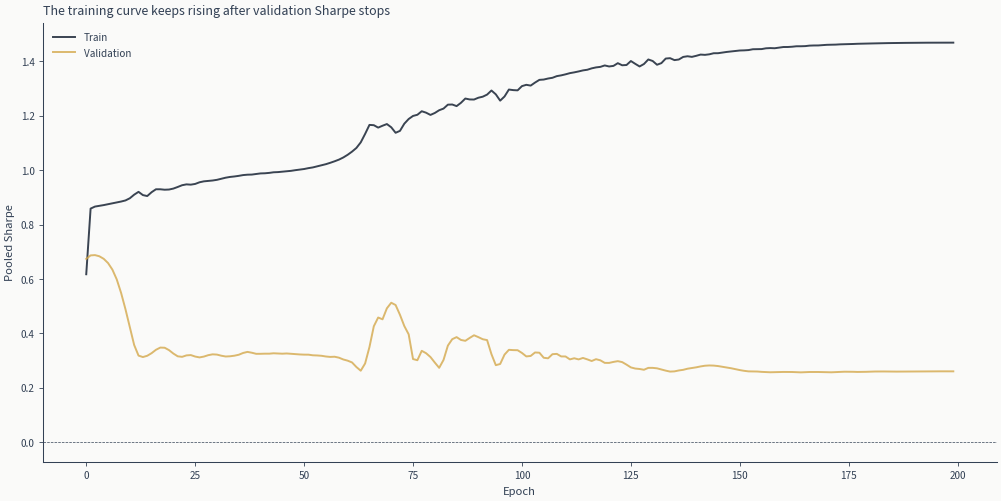

In [23]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(train_sharpes, label="Train", color=COLORS["blue"], alpha=0.8)
ax.plot(val_sharpes, label="Validation", color=COLORS["amber"], alpha=0.8)
ax.legend()
ax.axhline(0, color=COLORS["neutral"], linestyle="--", linewidth=0.5)
ax.set_xlabel("Epoch")
ax.set_ylabel("Pooled Sharpe")
ax.set_title("The training curve keeps rising after validation Sharpe stops")
show_with_alt(
    fig,
    "Training and validation pooled Sharpe against epoch, the training curve continuing to rise after the validation curve flattens, with a reference line at zero.",
)

## 12. Out-of-Sample Evaluation

The comparison holds data and test window constant so any Sharpe difference reflects
the allocator, not the universe or the time slice.

In [24]:
model.load_state_dict(best_state)
model.eval()

VLSTM(
  (vsn): VariableSelectionNetwork(
    (feature_grns): ModuleList(
      (0-4): 5 x GatedResidualNetwork(
        (skip): Linear(in_features=1, out_features=32, bias=True)
        (dense1): Linear(in_features=1, out_features=32, bias=True)
        (dense2): Linear(in_features=32, out_features=32, bias=True)
        (gate): Linear(in_features=32, out_features=64, bias=True)
        (dropout): Dropout(p=0.0, inplace=False)
        (norm): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
      )
    )
    (selector): GatedResidualNetwork(
      (skip): Identity()
      (dense1): Linear(in_features=5, out_features=32, bias=True)
      (dense2): Linear(in_features=32, out_features=5, bias=True)
      (gate): Linear(in_features=5, out_features=10, bias=True)
      (dropout): Dropout(p=0.0, inplace=False)
      (norm): LayerNorm((5,), eps=1e-05, elementwise_affine=True)
    )
  )
  (lstm): LSTM(32, 64, batch_first=True)
  (post_grn): GatedResidualNetwork(
    (skip): Identity()
   

Collect held-out signals, returns, and volatility estimates without gradients.

In [25]:
@torch.no_grad()
def collect_test_arrays():
    sig_last, ret_last, vol_last = [], [], []
    for x_batch, r_batch, v_batch in test_loader:
        x_batch = x_batch.to(DEVICE)
        r_batch = r_batch.to(DEVICE)
        v_batch = v_batch.to(DEVICE)
        signal, _ = model(x_batch)
        sig_last.append(signal[:, -1, :].cpu().numpy())
        ret_last.append(r_batch.cpu().numpy())
        vol_last.append(v_batch.cpu().numpy())
    return (
        np.concatenate(sig_last, axis=0),
        np.concatenate(ret_last, axis=0),
        np.concatenate(vol_last, axis=0),
    )


test_signal, test_fwd, test_vol = collect_test_arrays()

Convert a learned scalar signal into volatility-targeted position weights (numpy mirror of `vol_scaled_positions`).

In [26]:
def positions_from_signal(signal: np.ndarray, vol_est: np.ndarray) -> np.ndarray:
    ann_vol = np.maximum(vol_est, 1e-4) * (252.0**0.5)
    n_assets = signal.shape[-1]
    return (VOL_TARGET_ANN / (ann_vol * n_assets)) * signal

Compute net-of-cost portfolio returns from a weight matrix and forward returns, charging `cost_bps` on turnover.

In [27]:
def strategy_returns(weights: np.ndarray, fwd: np.ndarray, cost_bps: float) -> np.ndarray:
    prev = np.vstack([np.zeros_like(weights[:1]), weights[:-1]])
    gross = (weights * fwd).sum(axis=1)
    turnover = np.abs(weights - prev).sum(axis=1)
    cost = turnover * (cost_bps / 10_000.0)
    return gross - cost

In [28]:
# VLSTM weights.
vlstm_weights = positions_from_signal(test_signal, test_vol)
vlstm_ret = strategy_returns(vlstm_weights, test_fwd, TURNOVER_COST_BPS)

# Equal-weight long-only benchmark (weights sum to 1).
eq_weights = np.ones_like(test_fwd) / N_ASSETS
eq_ret = strategy_returns(eq_weights, test_fwd, cost_bps=TURNOVER_COST_BPS)

# Inverse-volatility long-only benchmark.
inv_vol = 1.0 / np.maximum(test_vol, 1e-4)
iv_weights = inv_vol / inv_vol.sum(axis=1, keepdims=True)
iv_ret = strategy_returns(iv_weights, test_fwd, cost_bps=TURNOVER_COST_BPS)

### Performance Metrics

In [29]:
def metrics(returns: np.ndarray, name: str) -> dict:
    r = pd.Series(returns)
    mu = r.mean() * 252.0
    sigma = r.std() * (252.0**0.5)
    sharpe = mu / (sigma + 1e-8)
    cum = (1 + r).cumprod()
    dd = float((cum / cum.cummax() - 1).min())
    return {
        "Method": name,
        "Ann. Return": f"{mu:.1%}",
        "Ann. Vol": f"{sigma:.1%}",
        "Sharpe": f"{sharpe:+.2f}",
        "Max DD": f"{dd:.1%}",
    }


results = pd.DataFrame(
    [
        metrics(vlstm_ret, "VLSTM (long-short, vol-targeted)"),
        metrics(eq_ret, "Equal Weight"),
        metrics(iv_ret, "Inverse Volatility"),
    ]
)
results

,Method,Ann. Return,Ann. Vol,Sharpe,Max DD
0,"VLSTM (long-short, vol-targeted)",8.6%,9.6%,+0.89,-10.7%
1,Equal Weight,10.0%,12.0%,+0.83,-13.4%
2,Inverse Volatility,6.6%,8.1%,+0.81,-10.9%


Compare the net held-out Sharpe ratios on a common annualized scale.

In [30]:
def _sharpe(r):
    return float(pd.Series(r).mean() * 252.0 / (pd.Series(r).std() * (252.0**0.5) + 1e-8))


vlstm_sharpe = _sharpe(vlstm_ret)
ew_sharpe = _sharpe(eq_ret)
iv_sharpe = _sharpe(iv_ret)
print(f"Held-out Sharpe at the {TURNOVER_COST_BPS:.0f} bp one-way cost charged in the loss:")
print(f"  VLSTM              {vlstm_sharpe:+.2f}")
print(f"  Equal weight       {ew_sharpe:+.2f}")
print(f"  Inverse volatility {iv_sharpe:+.2f}")

Held-out Sharpe at the 5 bp one-way cost charged in the loss:
  VLSTM              +0.89
  Equal weight       +0.83
  Inverse volatility +0.81


### Equity Curves

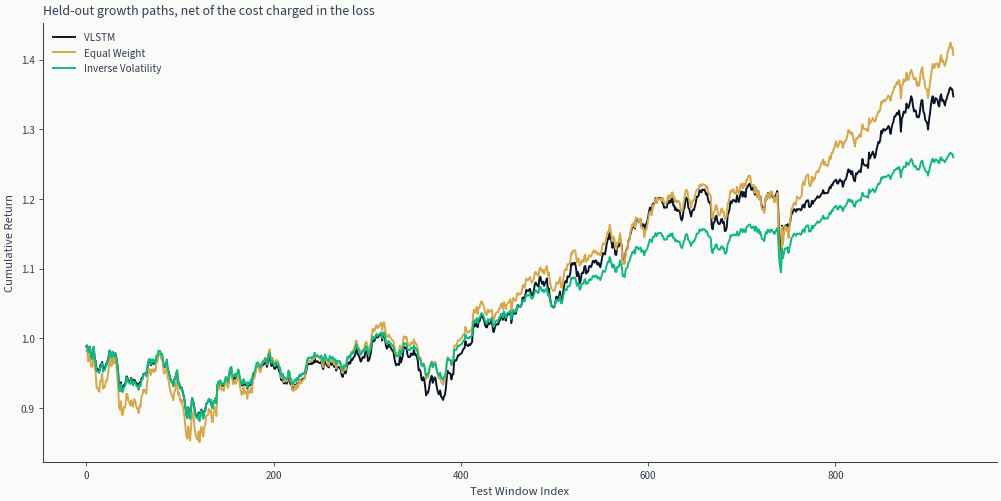

In [31]:
fig, ax = plt.subplots(figsize=(10, 5))
for arr, label, color in [
    (vlstm_ret, "VLSTM", COLORS["blue"]),
    (eq_ret, "Equal Weight", COLORS["amber"]),
    (iv_ret, "Inverse Volatility", COLORS["positive"]),
]:
    ax.plot(np.cumprod(1 + arr), label=label, color=color)
ax.set_xlabel("Test Window Index")
ax.set_ylabel("Cumulative Return")
ax.set_title("Held-out growth paths, net of the cost charged in the loss")
ax.legend()
show_with_alt(
    fig,
    "Three cumulative return paths over the test windows for the VLSTM, equal weight and inverse volatility, net of the cost charged in the loss.",
)

**Trading implication**: If the VLSTM curve does not clear both heuristics net of the
in-loss cost deduction, the added complexity is not yet earning its keep on this
universe and cost regime.

## 13. Signal and Position Diagnostics

The scalar signal sits in $(-1, 1)$ and is converted into a signed position by the
volatility-targeting layer. A well-behaved learned allocator should produce (a) a
signal distribution that uses the full tanh range rather than collapsing to zero, and
(b) turnover that reflects genuine regime change rather than a high-frequency random
walk around neutral.

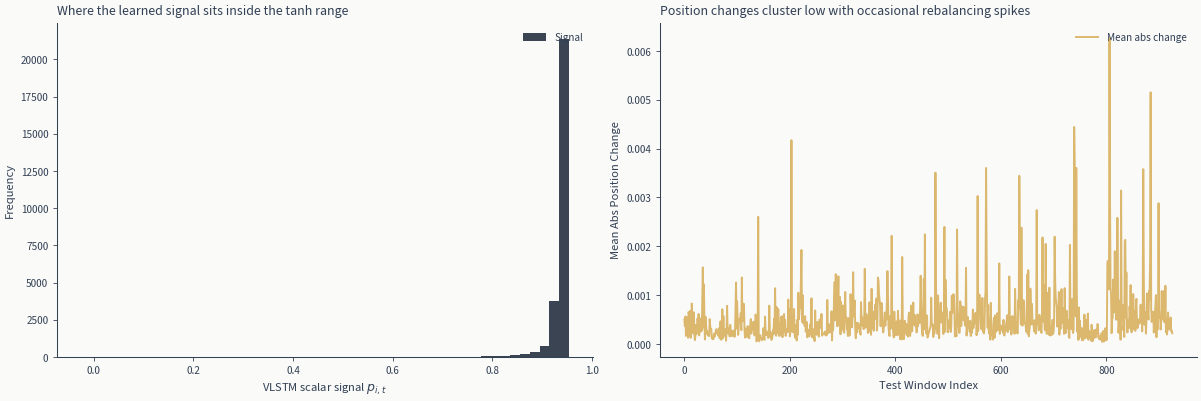

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

signal_at_bounds = float(np.mean(np.abs(test_signal) > 0.9))
axes[0].hist(test_signal.reshape(-1), bins=50, color=COLORS["blue"], alpha=0.8)
axes[0].set_xlabel("VLSTM scalar signal $p_{i,t}$")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Where the learned signal sits inside the tanh range")

mean_position_change = np.abs(np.diff(vlstm_weights, axis=0)).mean(axis=1)
axes[1].plot(
    mean_position_change,
    color=COLORS["amber"],
    alpha=0.8,
)
axes[1].set_xlabel("Test Window Index")
axes[1].set_ylabel("Mean Abs Position Change")
axes[1].set_title("Position changes cluster low with occasional rebalancing spikes")
axes[0].legend(["Signal"], loc="upper right")
axes[1].legend(["Mean abs change"], loc="upper right")

show_with_alt(
    fig,
    "Two panels: a histogram of the VLSTM's scalar signal across the tanh range on the left, and the mean absolute position change per test window on the right, low most of the time with occasional spikes.",
)

Read the left panel first. `positions_from_signal` multiplies its inverse-volatility scaling by
the signal, so the signal decides how much of the book is used at all. A distribution piled up
at zero is a network declining to take a position, and what results is a portfolio close to
flat - not the inverse-volatility benchmark, which the layer would only reproduce if the
signals were equal and non-zero across the assets. Signals away from zero produce exposure in
proportion to their size, so the histogram is read for how much of its range the network uses
rather than for whether it saturates: a book built from signals around a half is half the size
of one built from signals at the bound, and both are allocations.

The relative sizes within the book come from both terms at once: two assets with the same
signal are held in inverse proportion to their volatilities, and two with the same volatility
in proportion to their signals.

The right panel is where the cost lives, and it is worth being precise about whose change it
plots. A position is the inverse-volatility scaling multiplied by the signal, so it moves when
either term moves. The volatility estimate is a rolling standard deviation over `VOL_LOOKBACK`
sessions, so it usually drifts - but a rolling window is not smooth: a large return entering
or leaving it moves the estimate at once, and the position moves with it. So a spike in this
panel is the network changing its mind or the volatility estimate jumping, and the panel alone
cannot say which. Separating them would take the two series plotted apart. A level that stays
high says the positions are being churned every day whichever term is doing it, and section 15
prices what that would cost.

## 14. Variable Selection Weights

One reason to pay for VSN is interpretability. Averaging the selection weights over
the test period shows which inputs the model relies on.

Largest average selection weight: ret_5d at 65.8%, against 20.0% under uniform selection.


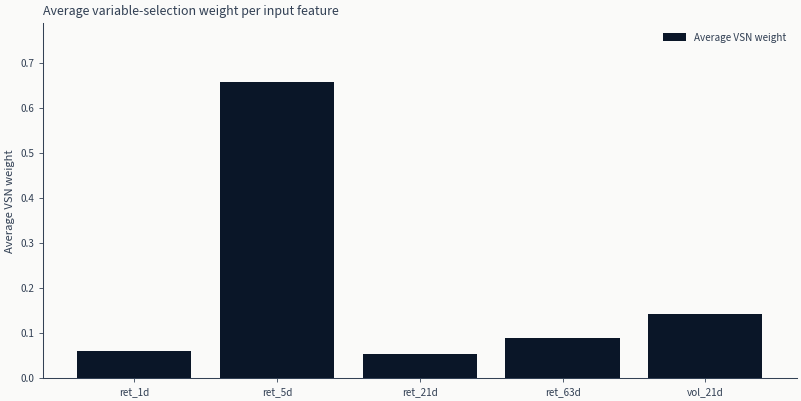

In [33]:
model.eval()
vsn_weights: list[np.ndarray] = []
with torch.no_grad():
    for x_batch, _, _ in test_loader:
        x_batch = x_batch.to(DEVICE)
        _, sel = model(x_batch)
        vsn_weights.append(sel[:, -1, :, :].cpu().numpy())
vsn_mean = np.concatenate(vsn_weights, axis=0).mean(axis=(0, 1))

feature_names = [f"ret_{h}d" for h in HORIZONS] + ["vol_21d"]
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(feature_names, vsn_mean, color=COLORS["blue"])
ax.legend(["Average VSN weight"], loc="upper right")
ax.set_ylabel("Average VSN weight")
top_feature = int(np.argmax(vsn_mean))
print(
    f"Largest average selection weight: {feature_names[top_feature]} at "
    f"{vsn_mean[top_feature]:.1%}, against {1 / len(feature_names):.1%} under uniform selection."
)
ax.set_title("Average variable-selection weight per input feature")
ax.set_ylim(0, max(vsn_mean.max() * 1.2, 1.0 / len(feature_names) * 2))
show_with_alt(
    fig,
    "Bars of the average variable-selection weight for each of the five input features, against a uniform reference implied by the feature count.",
)

**Finding**: A concentrated VSN distribution says the model reduced the effective
feature set; a near-uniform distribution says selection added little over a plain
encoder, which is itself a useful diagnostic for whether the variable-selection
machinery is paying for itself on this universe.

## 15. Cost Sensitivity

The training loss already subtracts a 5 bps one-way turnover cost. This stress test
varies that assumption post-hoc on held-out weights to show how quickly the Sharpe of
each allocator erodes.

In [34]:
cost_grid = [0, 5, 10, 20, 50]
cost_rows = []
for cost_bps in cost_grid:
    row = {"One-way cost (bps)": cost_bps}
    for name, w, fwd in [
        ("VLSTM", vlstm_weights, test_fwd),
        ("Equal Weight", eq_weights, test_fwd),
        ("Inverse Vol", iv_weights, test_fwd),
    ]:
        r = strategy_returns(w, fwd, cost_bps=cost_bps)
        row[name] = _sharpe(r)
    cost_rows.append(row)

cost_df = pd.DataFrame(cost_rows).set_index("One-way cost (bps)")
cost_df.round(2)

,VLSTM,Equal Weight,Inverse Vol
One-way cost (bps),,,
0,0.91,0.84,0.83
5,0.89,0.83,0.81
10,0.87,0.83,0.80
20,0.82,0.83,0.76
50,0.69,0.82,0.66


**Trading implication**: The cost grid reports only the assumptions computed in this notebook.

### What this run produced

One table of held-out metrics, one cost grid, and two diagnostics of what the network learned.

The table compares the VLSTM against equal weight and inverse volatility on the same universe
and the same test window that `11_dl_portfolio_allocation` uses. Two things stop the Sharpe
columns of the two notebooks being read against each other directly. `11` reports gross
returns and deducts nothing, while everything here is net of the one-way charge the loss was
trained against; the zero-cost row of the grid below removes that difference. The
inverse-volatility baselines also differ, because each notebook builds it from its own
volatility estimate - 21 sessions there, `VOL_LOOKBACK` sessions here - so even at zero cost
the two are not the same portfolio.

The cost grid is the number to read before the table. It recomputes each allocator's Sharpe at
five cost levels using the weights already produced, so it says how much of any advantage is a
property of the allocation and how much is a property of the cost assumed. A row that reorders
between 0 and 20 bps has not established an advantage; it has established one at a price.

The signal histogram and the selection-weight bars say what the network is doing rather than
how it scored. A signal that never leaves the neighbourhood of zero and selection weights near
uniform would mean the two pieces of machinery this notebook adds are not being used, whatever
the Sharpe column says.

## 16. Key Takeaways

1. **Variable selection is the architectural innovation.** The VSN is a soft gate over
   TFT-style per-feature GRN embeddings; it lets the LSTM ingest a denoised
   representation rather than the raw feature stack.
2. **The portfolio layer matters as much as the encoder.** Scalar signal → vol-targeted
   long-short weights is the layer evaluated here.
3. **Turnover cost is in the training loss, not added after the fact.** The model
   optimizes net-of-cost return at training time rather than receiving a post-hoc
   cost adjustment at evaluation. Whether the in-loss formulation strictly improves
   realized net Sharpe versus a post-hoc charge is not tested in this notebook.
4. **VLSTM is a variable-selection extension of the plain LSTM.** Comparisons with
   other architectures require their own matched implementation and evaluation.

**Next**: `13_deepm_regime_robust` adds regime-aware structure on top of this base.

**Book**: Section 17.8 places this implementation alongside related portfolio encoders.